In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/a-adegite/tb-isoniazid-mutation-analysis/refs/heads/main/results/table/mtb_isoniazid_resistance_mutations.csv")

In [3]:
df.head()

,Sample,Gene,POS (Chromosome),HGVS_c,HGVS_p,Type,WHO,Interpretation,Resistance_Level,Comment
0,ERR8774524,katG,2155168.0,c.944G>C,p.Ser315Thr,missense_variant,Assoc w R,Resistant,High,High-level resistance
1,ERR8774534,katG,2155168.0,c.944G>C,p.Ser315Thr,missense_variant,Assoc w R,Resistant,High,High-level resistance
2,ERR8774482,inhA,1673425.0,c.-777C>T,-,upstream_gene_variant,Assoc w R,Resistant,Low,"Low-level resistance (multiple, genetically li..."
3,ERR8774480,inhA,1673426.0,c.-777C>T,-,upstream_gene_variant,Assoc w R,Resistant,Low,"Low-level resistance (multiple, genetically li..."
4,ERR8774458,inhA,1673393.0,c.-809G>C,-,upstream_gene_variant,Uncertain Significance,Uncertain,Unknown,Variant of uncertain significance; insufficien...


In [4]:
# Global style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300

In [5]:
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n(n={count})"
    return inner

/tmp/ipykernel_6517/1461988537.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Mutation", y="Count", data=mut_freq, palette="viridis")


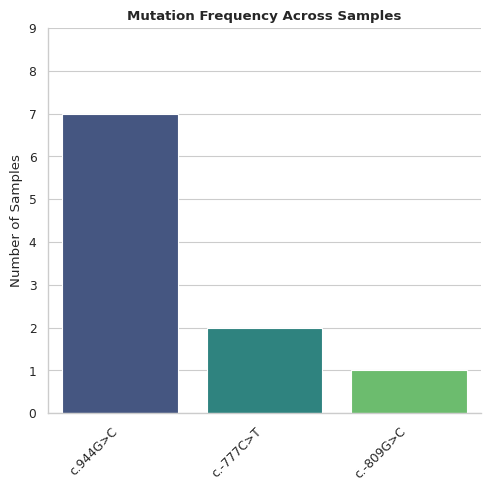

In [6]:
# Mutation Frequency
plt.figure(figsize=(5,5))
sns.set_theme(style="whitegrid", context="paper")

mut_freq = df["HGVS_c"].value_counts().reset_index()
mut_freq.columns = ["Mutation","Count"]

sns.barplot(x="Mutation", y="Count", data=mut_freq, palette="viridis")

plt.title("Mutation Frequency Across Samples", fontweight="bold")
plt.ylabel("Number of Samples")
plt.xlabel("")
plt.ylim(0,9)
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.savefig("mutation_frequency.png", bbox_inches="tight")
plt.show()

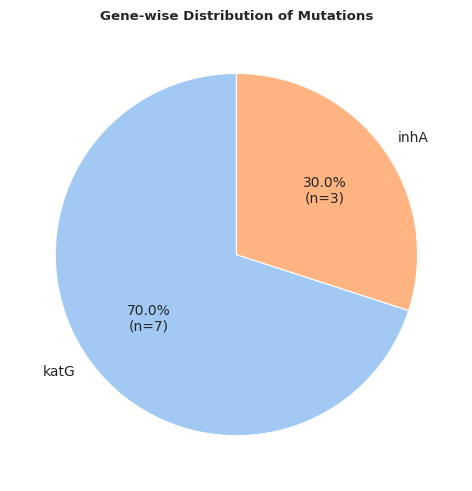

In [7]:
# Gene Distribution
plt.figure(figsize=(5,5))

gene_counts = df["Gene"].value_counts()

plt.pie(
    gene_counts.values,
    labels=gene_counts.index,
    autopct=autopct_format(gene_counts.values),
    startangle=90,
    colors=sns.color_palette("pastel"),
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 10}
)

plt.title("Gene-wise Distribution of Mutations", fontweight="bold")
plt.tight_layout()
plt.savefig("gene_distribution.png", bbox_inches="tight")
plt.show()

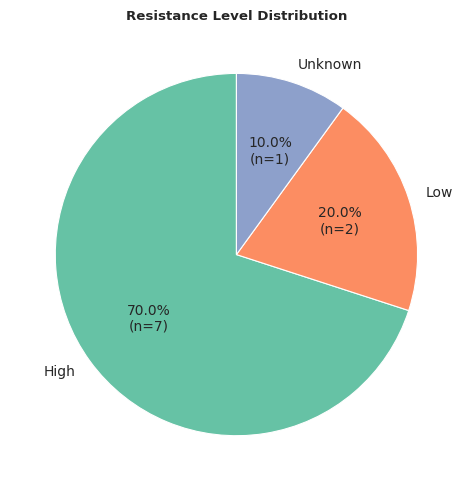

In [8]:
# Resistance Levels
plt.figure(figsize=(5,5))

res_counts = df["Resistance_Level"].value_counts()

plt.pie(
    res_counts.values,
    labels=res_counts.index,
    autopct=autopct_format(res_counts.values),
    startangle=90,
    colors=sns.color_palette("Set2"),
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 10}
)

plt.title("Resistance Level Distribution", fontweight="bold")
plt.tight_layout()
plt.savefig("resistance_levels.png", bbox_inches="tight")
plt.show()

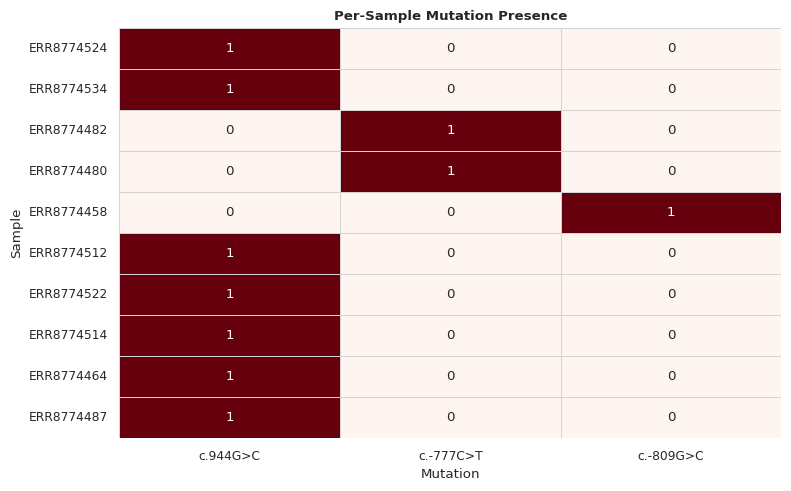

In [9]:
# Presence matrix
# Build matrix
samples = df["Sample"].unique()
mutations = df["HGVS_c"].unique()

data_matrix = pd.DataFrame(0, index=samples, columns=mutations)

for _, row in df.iterrows():
    data_matrix.at[row["Sample"], row["HGVS_c"]] = 1

plt.figure(figsize=(8,5))

sns.heatmap(
    data_matrix,
    annot=True,
    cbar = False,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Presence"},

)

plt.title("Per-Sample Mutation Presence", fontweight="bold")
plt.xlabel("Mutation")
plt.ylabel("Sample")

plt.tight_layout()
plt.savefig("per_sample_heatmap.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_6517/315192324.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Mutation", y="Count", data=mut_freq, palette="viridis", ax=axes[0,0])


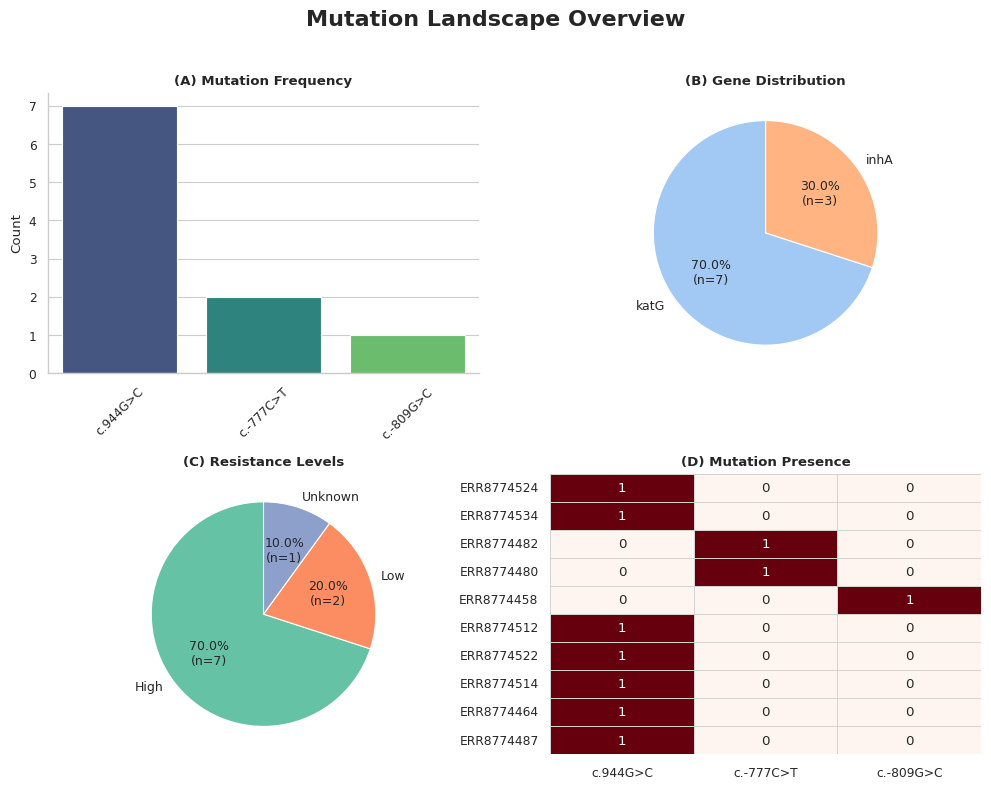

In [15]:
# Final Combined Panel
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Mutation Landscape Overview", fontsize=16, fontweight="bold")

# (A)
sns.barplot(x="Mutation", y="Count", data=mut_freq, palette="viridis", ax=axes[0,0])
axes[0,0].set_title("(A) Mutation Frequency", fontweight="bold")
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_xlabel("")
sns.despine(ax=axes[0,0])

# (B)
axes[0,1].pie(
    gene_counts.values,
    labels=gene_counts.index,
    autopct=autopct_format(gene_counts.values),
    startangle=90,
    colors=sns.color_palette("pastel"),
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 9}
)
axes[0,1].set_title("(B) Gene Distribution", fontweight="bold")

# (C)
axes[1,0].pie(
    res_counts.values,
    labels=res_counts.index,
    autopct=autopct_format(res_counts.values),
    startangle=90,
    colors=sns.color_palette("Set2"),
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 9}
)
axes[1,0].set_title("(C) Resistance Levels", fontweight="bold")

# (D)
sns.heatmap(
    data_matrix,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    linecolor="lightgray",
    cbar=False,
    ax=axes[1,1]
)
axes[1,1].set_title("(D) Mutation Presence", fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("mutation_landscape.png", bbox_inches="tight")
plt.show()